In [119]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [120]:
demand_history_raw_data = pd.read_parquet('../data/synthetic1/demand_history.parquet')
demand_history_raw_data.head(10)

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
0,2025-01-01,D01,48.87,2,False,0
1,2025-01-02,D01,43.73,3,False,0
2,2025-01-03,D01,47.48,4,False,0
3,2025-01-04,D01,41.60,5,True,0
4,2025-01-05,D01,46.25,6,True,1
5,2025-01-06,D01,44.57,0,False,0
6,2025-01-07,D01,40.87,1,False,0
7,2025-01-08,D01,58.83,2,False,1
8,2025-01-09,D01,48.30,3,False,0
9,2025-01-10,D01,46.24,4,False,0


In [121]:
demand_history_raw_data["destination_id"].unique()

<ArrowStringArray>
['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08']
Length: 8, dtype: str

In [122]:
destination = 'D03'

In [123]:
d1_demand_history = demand_history_raw_data[demand_history_raw_data['destination_id'] == destination]
d1_demand_history

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
362,2025-01-01,D03,77.61,2,False,1
363,2025-01-02,D03,61.43,3,False,0
364,2025-01-03,D03,56.06,4,False,0
365,2025-01-04,D03,59.00,5,True,0
366,2025-01-05,D03,53.18,6,True,0
...,...,...,...,...,...,...
538,2025-06-26,D03,77.42,3,False,0
539,2025-06-27,D03,75.75,4,False,0
540,2025-06-28,D03,61.74,5,True,0
541,2025-06-29,D03,82.23,6,True,1


In [124]:
type(d1_demand_history)

pandas.DataFrame

In [125]:
import polars as pl
moving_average_df = d1_demand_history[["date", "destination_id", "demand"]].sort_values("date")
polars_moving_average = pl.from_pandas(moving_average_df)

In [126]:
from forecasting.models.rolling_window_forecaster import RollingWindowForecaster

forecaster = RollingWindowForecaster(rolling_window= 7)

moving_average_df = forecaster.predict(polars_moving_average)
moving_average_df.head(10)

date,destination_id,demand,ma_7_forecast
date,str,f64,f64
2025-01-01,"""D03""",77.61,null
2025-01-02,"""D03""",61.43,null
2025-01-03,"""D03""",56.06,null
2025-01-04,"""D03""",59.0,null
2025-01-05,"""D03""",53.18,null
2025-01-06,"""D03""",61.51,null
2025-01-07,"""D03""",57.18,null
2025-01-08,"""D03""",61.88,60.852857
2025-01-09,"""D03""",61.53,58.605714


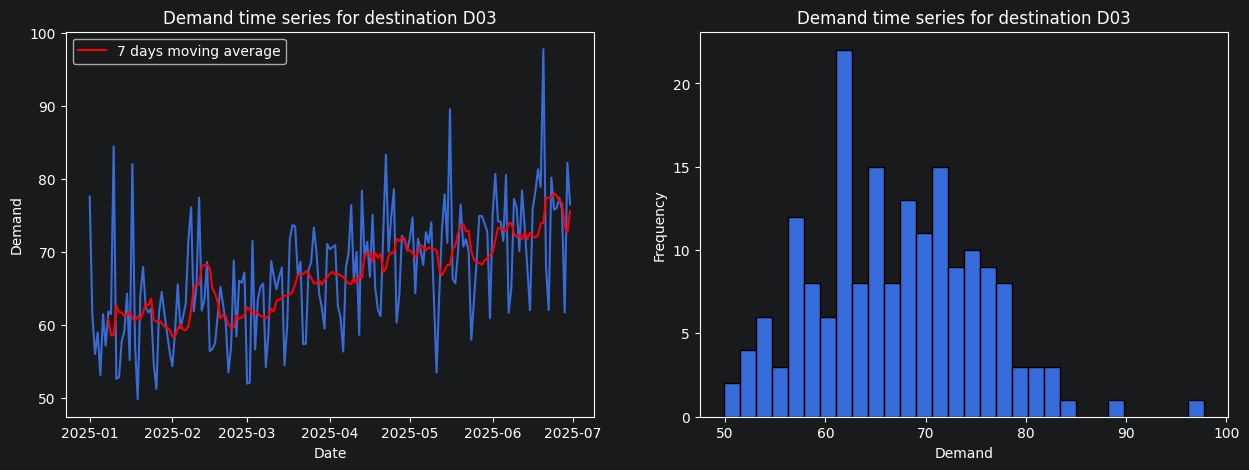

In [127]:
fig, (plot_ax, hist_ax) = plt.subplots(1, 2, figsize=(15, 5))

plot_ax.plot(d1_demand_history['date'], d1_demand_history['demand'])
plot_ax.set_xlabel("Date")
plot_ax.set_ylabel("Demand")
plot_ax.set_title(f'Demand time series for destination {destination}')

hist_ax.hist( d1_demand_history['demand'], bins = 30, edgecolor = 'black')
hist_ax.set_xlabel("Demand")
hist_ax.set_ylabel("Frequency")
hist_ax.set_title(f'Demand time series for destination {destination}')

plot_ax.plot(
    moving_average_df["date"],
    moving_average_df["ma_7_forecast"],
    color = 'red',
    label = '7 days moving average'
             )

plot_ax.legend()

plt.show()

In [128]:
# I want to compute mean squared error
df_eval = moving_average_df.drop_nulls()

mse = mean_squared_error(df_eval['demand'], df_eval['ma_7_forecast'])
print("Mean squared error: %f" % mse)


Mean squared error: 50.320452


In [129]:
moving_average_df

date,destination_id,demand,ma_7_forecast
date,str,f64,f64
2025-01-01,"""D03""",77.61,null
2025-01-02,"""D03""",61.43,null
2025-01-03,"""D03""",56.06,null
2025-01-04,"""D03""",59.0,null
2025-01-05,"""D03""",53.18,null
…,…,…,…
2025-06-26,"""D03""",77.42,76.965714
2025-06-27,"""D03""",75.75,76.751429
2025-06-28,"""D03""",61.74,73.605714


The formula is the following:

$
\rho_k = \frac{\sum_{i=k+1}^{T} (y_i - \bar{y})(y_{i-k} - \bar{y})}{\sum_{i=1}^{T} (y_i - \bar{y})^2}
$

Let's compute the ACF function in Polars, with lag autocorrelation values ranging from 1 to 7

In [130]:
demand_series = moving_average_df["demand"].to_pandas()
max_lag = 28

In [131]:
acf_values = [demand_series.autocorr(lag = lag) for lag in range(1, max_lag)]

Autocorrelation value of lag 1: 0.37648183004357755
Autocorrelation value of lag 7: 0.5669174744996293
Autocorrelation value of lag 13: 0.3545529737618861
Autocorrelation value of lag 19: 0.19913689185214153
Autocorrelation value of lag 25: 0.14795267341813848


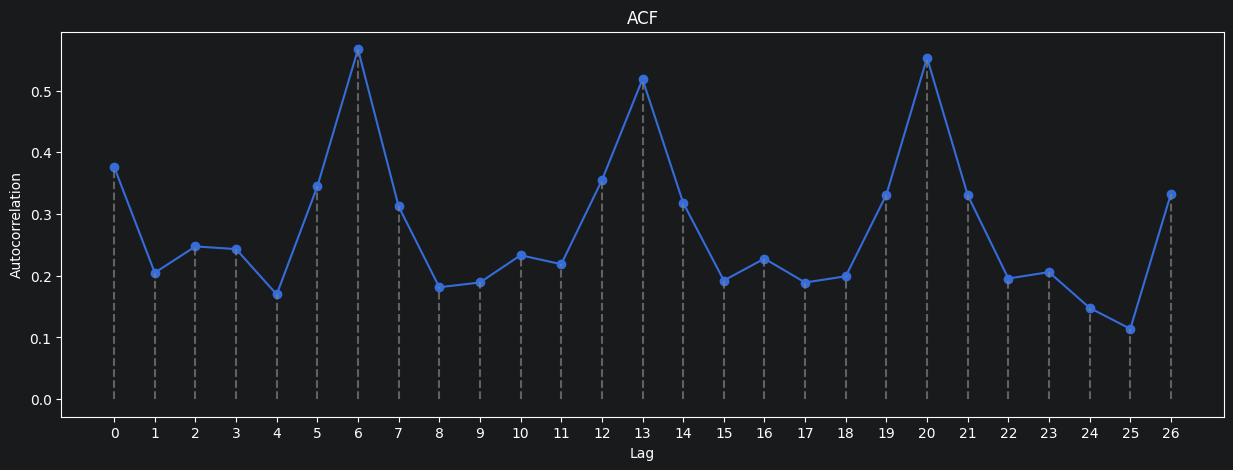

In [132]:
for lag in range(0, max_lag-1, 6):
    print(f"Autocorrelation value of lag {lag + 1}: {acf_values[lag]}")

fig, ax = plt.subplots(figsize=(15, 5))

lags = list(range(len(acf_values)))

ax.plot(lags, acf_values, marker="o")

ax.vlines(
    x=lags,
    ymin=0,
    ymax=acf_values,
    colors="gray",
    linestyles="dashed",
    alpha=0.7
)

ax.set_xlabel("Lag")
ax.set_xticks(lags)
ax.set_ylabel("Autocorrelation")
ax.set_title("ACF")

plt.show()

Hence, there is a strong autocorrelation value between $y_{t}$ and $y_{t - k}$